# Preprocessing

Important imports

In [340]:
import numpy as np
import os
import time
import matplotlib.pyplot as plt

np.random.seed(123) # REMOVEME

## Loading dataset

### Loading string data

**Parameters:**
- `data_string`: A string containing the data in the format:
  - First line: number of jobs and number of machines (e.g., "10 10")
  - Following lines: for each job, alternating machine numbers and processing times

**Returns:**
- `np.ndarray`: A numpy array of shape `(num_jobs, num_machines, 2)` where the last dimension is `[machine, time]` pairs.

In [341]:
def load_from_string(data_string):
    lines = data_string.strip().split('\n')
    
    num_jobs, num_machines = map(int, lines[0].split())
    
    data = []
    for i in range(1, num_jobs + 1):
        nums = list(map(int, lines[i].split()))
        pairs = [[nums[j], nums[j+1]] for j in range(0, len(nums), 2)]
        data.append(pairs)
    
    return np.array(data)

### Loading txt file

**Parameters:**
- `key`: The instance key (e.g., 'abz5', 'ft06', 'la01') to load from the dataset.
- `filepath`: Path to the jobshop.txt file. Default is `./data/jobshop.txt`.

**Returns:**
- `np.ndarray`: A numpy array of shape `(num_jobs, num_machines, 2)` where the last dimension is `[machine, time]` pairs.

In [342]:
def load_from_dataset(key, filepath=os.path.join('.', 'data', 'jobshop.txt')):    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset file not found at {filepath}")
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    instance_marker = f'instance {key}'
    start_idx = None
    
    for i, line in enumerate(lines):
        if instance_marker in line:
            start_idx = i
            break
        
    
    if start_idx is None:
        raise ValueError(f"Instance '{key}' not found in the dataset")
    
    dimensions_line = None
    data_start_idx = None
    
    for i in range(start_idx, min(start_idx + 10, len(lines))):
        line = lines[i].strip()
        if line and line[0].isdigit():
            parts = line.split()
            if len(parts) >= 2 and all(p.isdigit() for p in parts[:2]):
                dimensions_line = line
                data_start_idx = i + 1
                break
    
    if dimensions_line is None:
        raise ValueError(f"Could not parse dimensions for instance '{key}'")
    
    num_jobs, _ = map(int, dimensions_line.split()[:2])
    
    data = []
    for i in range(data_start_idx, data_start_idx + num_jobs):
        if i < len(lines):
            line = lines[i].strip()
            if line and not line.startswith('+'):
                nums = list(map(int, line.split()))
                pairs = [[nums[j], nums[j+1]] for j in range(0, len(nums), 2)]
                data.append(pairs)
    
    if len(data) != num_jobs:
        raise ValueError(f"Expected {num_jobs} jobs, but found {len(data)}")
    
    return np.array(data)

---

# Algorithms

## Simulated Annealing

### Generating an initial random solution

As we know the number of jobs and of machines, we can proceed to create an initial random solution.

In [343]:
def generate_random_solution(num_jobs, num_machines):
    # This function generates a random candidate solution for the job shop scheduling problem.
    steps_job = np.zeros(num_jobs, dtype=int)
    candidate_solution = np.zeros(num_jobs * num_machines, dtype=int) # This array will hold the sequence of job assignments for the candidate solution.
    counter = 0
    while (steps_job != np.repeat(num_machines, num_jobs)).any(): # This loop continues until all jobs have been assigned to all machines.
        random_job = np.random.randint(num_jobs)
        while steps_job[random_job] == num_machines:
            random_job = np.random.randint(num_jobs)
        candidate_solution[counter] = random_job # Assign the random job to the current position in the candidate solution.
        counter += 1
        steps_job[random_job] += 1
    return candidate_solution   # Return the generated random candidate solution.

### Calculate the makespan for a candidate solution

With this function we calculate how much time is spent by a candidate solution to schedule all the assigned tasks.

In [344]:
def compute_sa_makespan(candidate_solution, result_from_dataset):
    num_jobs, num_machines, _ = result_from_dataset.shape
    steps_job = np.zeros(num_jobs, dtype=int)
    steps_machines = np.zeros(num_machines, dtype=int)
    machines = np.array(np.repeat([np.repeat(np.zeros(shape=(1, 4)), num_jobs, axis=0)], num_machines, axis=0), dtype=int)
    time = 0
    for job in candidate_solution:
        machine, processing_time = result_from_dataset[job, steps_job[job]]
        if steps_job[job] > 0:
            machine_used_for_job, _ = result_from_dataset[job, steps_job[job] - 1]
            if machines[machine_used_for_job][steps_machines[machine_used_for_job] - 1][3] > time:
                # if a machine has been employed already for the same job and is not available at the current time
                # the time is updated to the time when the machine will be available
                time = machines[machine_used_for_job][steps_machines[machine_used_for_job] - 1][3]
        if machines[machine][steps_machines[machine] - 1][3] > time:
            # if a machine is used already for another job and is not available at the current time
            # the time is updated to the time when the machine will be available
            time = machines[machine][steps_machines[machine] - 1][3]
        machines[machine][steps_machines[machine]] = [job, steps_job[job], time, time + processing_time]
        steps_job[job] += 1
        steps_machines[machine] += 1
    return time

### Tweak a candidate solution

With this function the position of two random indexes of the candidate solution are swapped, in order to obtain a new candidate solution.

In [345]:
def tweak_candidate_solution(candidate_solution):
    index_one, index_two = np.random.randint(len(candidate_solution)), np.random.randint(len(candidate_solution))
    while index_one == index_two:
        index_two = np.random.randint(len(candidate_solution))
    candidate_solution[index_one], candidate_solution[index_two] = candidate_solution[index_two], candidate_solution[index_one] 
    return candidate_solution

### Main loop

Why this function has been chosen as the trajectory based function?
> It is flexible, and allows us to get from high exploration at the beginning to high exploitation at the end.

In [346]:
def simulated_annealing(input_solution, data, t = 120, target_time = 60):
    candidate_solution = input_solution.copy()
    best_solution = candidate_solution.copy()
    best_makespan = compute_sa_makespan(best_solution, data)
    history = [best_makespan]
    while t > 0 and best_makespan > target_time: 
        tweaked_solution = tweak_candidate_solution(candidate_solution.copy())
        tweaked_makespan = compute_sa_makespan(tweaked_solution, data)
        candidate_makespan = compute_sa_makespan(candidate_solution, data)
        quality_temp_ratio = -(tweaked_makespan - candidate_makespan) / t
        
        if tweaked_makespan < candidate_makespan or np.random.rand() < np.exp(quality_temp_ratio):
            candidate_solution = tweaked_solution

        if candidate_makespan < best_makespan:
            best_solution = candidate_solution.copy()
            best_makespan = candidate_makespan
        history.append(best_makespan)
        t -= 1


    return best_solution, best_makespan, history

### Testing functions for dataset abz5

In [347]:
result_from_dataset = load_from_dataset('abz5')
num_jobs, num_machines, _ = result_from_dataset.shape
candidate_solution = generate_random_solution(num_jobs, num_machines)
print(candidate_solution, compute_sa_makespan(candidate_solution, result_from_dataset))
best_solution, best_makespan, _ = simulated_annealing(candidate_solution, result_from_dataset)
print(best_solution, best_makespan)

[2 2 6 1 3 9 6 1 0 1 9 0 0 9 3 4 0 0 4 1 7 3 2 4 7 2 4 8 0 7 9 3 4 6 1 5 6
 2 1 8 3 5 0 2 6 2 4 4 6 3 0 6 4 7 6 7 1 5 7 9 2 4 8 1 2 1 1 3 5 9 0 8 6 3
 3 5 9 7 9 2 3 8 6 9 7 9 4 0 5 8 8 7 7 8 8 8 5 5 5 5] 3516
[4 1 2 4 3 9 5 1 0 3 1 0 8 9 6 5 8 2 4 9 1 0 2 9 3 9 4 8 1 7 6 7 7 9 7 0 6
 1 2 8 2 5 0 2 6 2 4 8 6 3 8 6 0 0 6 3 2 5 6 9 1 3 4 1 8 1 7 3 5 6 2 0 6 9
 3 5 5 2 7 4 7 7 4 4 3 9 4 3 5 7 0 1 5 8 8 8 0 9 5 7] 2554


## Evolution Strategy (μ + λ) 

### Data representation

An individual is a **permutation** of length `num_jobs * num_machines`, where each job index appears exactly `num_machines` times.

In [348]:
def create_individual(num_jobs, num_machines):
    individual = np.repeat(np.arange(num_jobs), num_machines)
    np.random.shuffle(individual)
    return individual

def create_population(size, num_jobs, num_machines):
    return [create_individual(num_jobs, num_machines) for _ in range(size)]

### Fitness function

The fitness function is **makespan** -> total completion time of all jobs. Since we are trying to minimize completition time -> **lower makespan = better fitness**.

In [349]:
def compute_es_makespan(individual, data):
    num_jobs, num_machines, _ = data.shape
    
    job_op_count = np.zeros(num_jobs, dtype=int)
    job_end_time = np.zeros(num_jobs, dtype=int)
    machine_end_time = np.zeros(num_machines, dtype=int)
    
    for gene in individual:
        j = gene
        k = job_op_count[j]
        machine_id, proc_time = data[j, k, :]
        
        start = max(job_end_time[j], machine_end_time[machine_id])
        end = start + proc_time
        
        job_end_time[j] = end
        machine_end_time[machine_id] = end
        job_op_count[j] += 1
    
    return np.max(job_end_time)

### Swap Mutation

For mutation we pick two random positions and swap their values. This also ensures that each job still appears the correct number of times  

The `step_size` controls mutation strength by determining **how many swaps** to perform. Larger step size means more mutations (more exploration), while smaller step size results in more exploitation

In [350]:
def mutate(individual, step_size):
    child = individual.copy()
    num_swaps = max(1, int(step_size + 0.5))
    length = len(child)
    
    for _ in range(num_swaps):
        i, j = np.random.randint(0, length, size=2)
        child[i], child[j] = child[j], child[i]
    
    return child

### Self-Adaptation

**Rechenberg's 1/5 Success Rule** adapts the mutation strenght based on success rate:

- **Success rate > 1/5**: Too much exploitation - more than 1/5 offspring are better than the parents -> **increase** the mutation strength  
- **Success rate < 1/5**: Too much exploration - more than 1/5 offspring are better than the parents -> **decrease** the mutation strength  
- **Success rate = 1/5**: don't change anything  

In [351]:
def self_adaptation(sigma, success_count, total_offspring, c, sigma_min=1.0, sigma_max=float('inf')):
    if total_offspring == 0:
        return sigma
    
    success_rate = success_count / total_offspring
    
    if success_rate > 0.2:
        sigma = sigma / c
    elif success_rate < 0.2:
        sigma = sigma * c

    return np.clip(sigma, sigma_min, sigma_max)

### Main loop

Implementation of **Algorithm 19** from the Essentials of Metaheuristics by Sean Luke

In [352]:
def evolution_strategy(data, mu, lam, max_generations, c=0.85):
    num_jobs, num_machines, _ = data.shape
    genome_length = num_jobs * num_machines
    sigma = genome_length / 10
    sigma_min = 1.0
    sigma_max = genome_length / 2
    
    population = create_population(mu + lam, num_jobs, num_machines)
    fitness = [compute_es_makespan(ind, data) for ind in population]
    
    best_idx = np.argmin(fitness)
    best_individual = population[best_idx].copy()
    best_makespan = fitness[best_idx]
    history = [best_makespan]
    
    for gen in range(max_generations):
        sorted_indices = np.argsort(fitness)[:mu]
        parents = [population[i] for i in sorted_indices]
        parent_fitness = [fitness[i] for i in sorted_indices]
        
        offspring_per_parent = lam // mu
        offspring = []
        offspring_fitness = []
        success_count = 0
        
        for p_idx in range(mu):
            for _ in range(offspring_per_parent):
                child = mutate(parents[p_idx], sigma)
                child_fit = compute_es_makespan(child, data)
                offspring.append(child)
                offspring_fitness.append(child_fit)
                if child_fit < parent_fitness[p_idx]:
                    success_count += 1
        
        remainder = lam - offspring_per_parent * mu
        for r in range(remainder):
            p_idx = r % mu
            child = mutate(parents[p_idx], sigma)
            child_fit = compute_es_makespan(child, data)
            offspring.append(child)
            offspring_fitness.append(child_fit)
            if child_fit < parent_fitness[p_idx]:
                success_count += 1
        
        population = parents + offspring
        fitness = parent_fitness + offspring_fitness
        
        total_offspring = len(offspring)
        sigma = self_adaptation(sigma, success_count, total_offspring, c, sigma_min, sigma_max)
        
        gen_best_idx = np.argmin(fitness)
        if fitness[gen_best_idx] < best_makespan:
            best_individual = population[gen_best_idx].copy()
            best_makespan = fitness[gen_best_idx]
        
        history.append(best_makespan)
    
    return best_individual, best_makespan, history

---

# Visualizations

## Datasets performance

Running multiple datasets of different sizes to observe results and computation time

[ft06] (6 jobs, 6 machines)
[ES] [ft06] Best makespan found: 59, finished in 3.17 seconds
[SA] [ft06] Best makespan found: 93, finished in 0.18 seconds


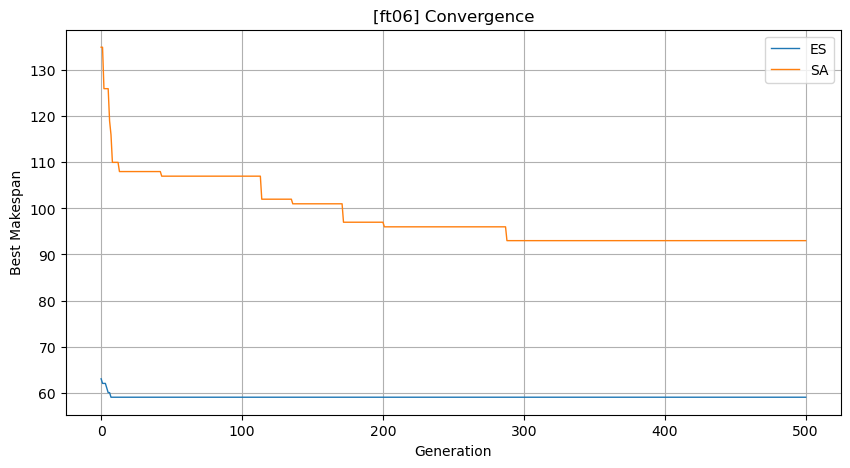

[abz5] (10 jobs, 10 machines)
[ES] [abz5] Best makespan found: 1363, finished in 7.80 seconds
[SA] [abz5] Best makespan found: 2795, finished in 0.62 seconds


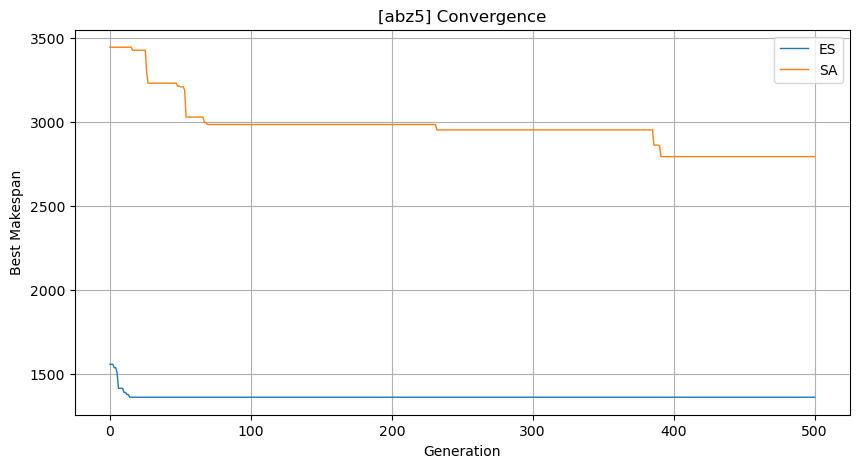

[la36] (15 jobs, 15 machines)


KeyboardInterrupt: 

In [24]:
es_full_history = []
sa_full_history = []

GENERATIONS = 500

for dataset_name in ['ft06', 'abz5', 'la36', 'swv10']:
    data = load_from_dataset(dataset_name)
    num_jobs, num_machines, _ = data.shape
    label = f"{dataset_name} ({num_jobs} x {num_machines})"
    print(f"[{dataset_name}] ({num_jobs} jobs, {num_machines} machines)")

    # es
    start_time = time.time()
    _, es_makespan, es_history = evolution_strategy(data, mu=10, lam=70, max_generations=GENERATIONS)
    es_time = time.time() - start_time

    print(f"[ES] [{dataset_name}] Best makespan found: {es_makespan}, finished in {es_time:.2f} seconds")

    es_full_history.append((es_history, label))

    # sa
    start_time = time.time()
    candidate_solution = generate_random_solution(num_jobs, num_machines)
    _, sa_makespan, sa_history = simulated_annealing(candidate_solution, data, t=GENERATIONS, target_time=0)
    sa_time = time.time() - start_time

    print(f"[SA] [{dataset_name}] Best makespan found: {sa_makespan}, finished in {sa_time:.2f} seconds")

    label = f"{dataset_name} ({num_jobs} x {num_machines})"
    sa_full_history.append((sa_history, label))

    plt.figure(figsize=(10, 5))
    plt.plot(es_history, linewidth=1, label='ES')
    plt.plot(sa_history, linewidth=1, label='SA')
    plt.xlabel('Generation')
    plt.ylabel('Best Makespan')
    plt.title(f'[{dataset_name}] Convergence')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.show()


## Normalised plot

### Evolution Strategy

Multiple runs showed that smaller datasets (usually) need much less generations than for larger datasets to get better results. Results were not as stable as expected though, sometimes even smallest dataset took much more generations to get best result.

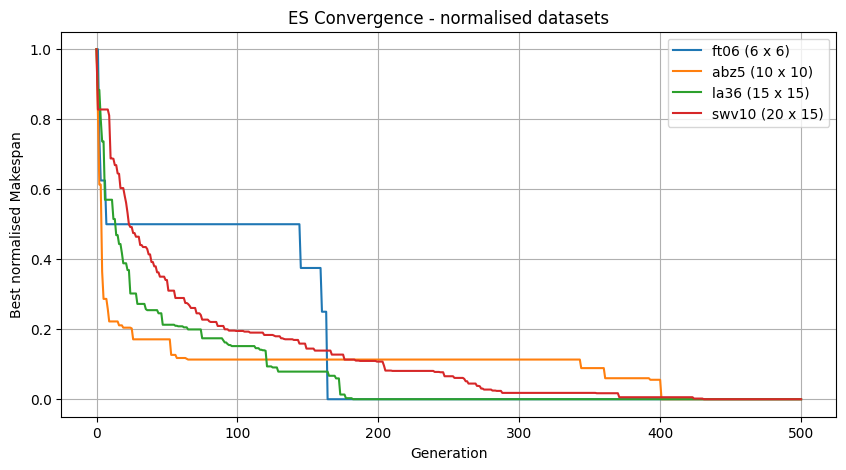

In [ ]:
plt.figure(figsize=(10, 5))
for history, label in es_full_history:
    arr = np.array(history)
    min_val, max_val = arr.min(), arr.max()
    norm = (arr - min_val) / (max_val - min_val)
    plt.plot(norm, label=label)
plt.xlabel('Generation')
plt.ylabel('Best normalised Makespan')
plt.title('ES Convergence - normalised datasets')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

### Simulated Annealing

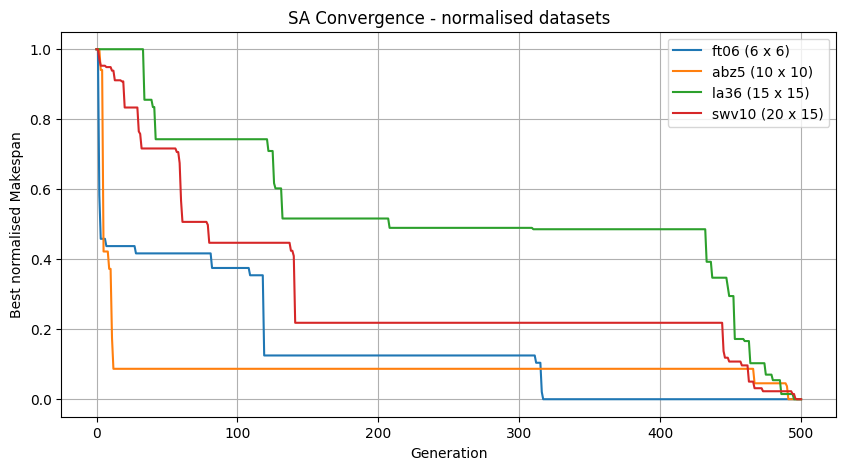

In [ ]:
plt.figure(figsize=(10, 5))
for history, label in sa_full_history:
    arr = np.array(history)
    min_val, max_val = arr.min(), arr.max()
    norm = (arr - min_val) / (max_val - min_val)
    plt.plot(norm, label=label)
plt.xlabel('Generation')
plt.ylabel('Best normalised Makespan')
plt.title('SA Convergence - normalised datasets')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Parameter optimisation 
Different values for the temperature are tested to compare accuracies in the Simulated Annealing algorithm, for dataset la36

[la36] (15 jobs, 15 machines)
[SA] [la36] Best makespan found: 3888, finished in 0.21 seconds
[la36] (15 jobs, 15 machines)
[SA] [la36] Best makespan found: 3687, finished in 1.02 seconds
[la36] (15 jobs, 15 machines)
[SA] [la36] Best makespan found: 3519, finished in 2.18 seconds
[la36] (15 jobs, 15 machines)
[SA] [la36] Best makespan found: 3849, finished in 13.69 seconds
[la36] (15 jobs, 15 machines)
[SA] [la36] Best makespan found: 3720, finished in 28.79 seconds
[la36] (15 jobs, 15 machines)
[SA] [la36] Best makespan found: 3877, finished in 58.15 seconds


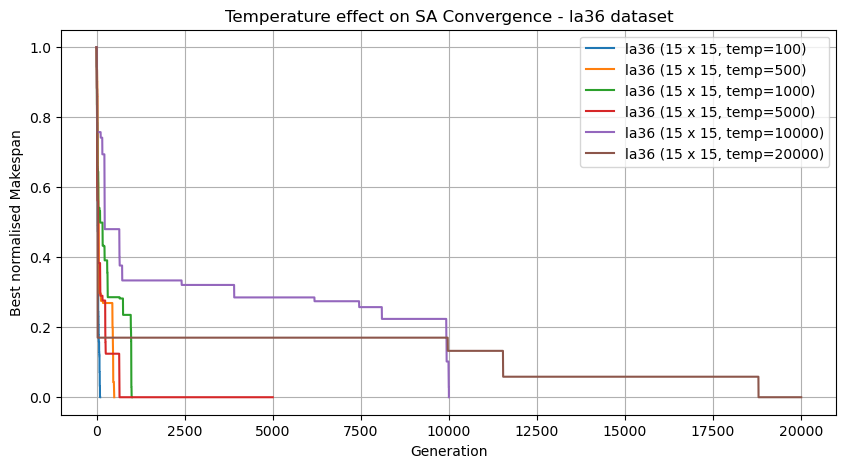

In [25]:
sa_full_history_la36 = []

for temp in [100, 500, 1000, 5000, 10000, 20000]:
    data = load_from_dataset('la36')
    num_jobs, num_machines, _ = data.shape
    label = f"la36 ({num_jobs} x {num_machines}, temp={temp})"
    print(f"[la36] ({num_jobs} jobs, {num_machines} machines)")

    # sa
    start_time = time.time()
    candidate_solution = generate_random_solution(num_jobs, num_machines)
    _, sa_makespan, sa_history = simulated_annealing(candidate_solution, data, t=temp, target_time=0)
    sa_time = time.time() - start_time

    print(f"[SA] [{dataset_name}] Best makespan found: {sa_makespan}, finished in {sa_time:.2f} seconds")
    
    sa_full_history_la36.append((sa_history, label))


plt.figure(figsize=(10, 5))
for history, label in sa_full_history_la36:
    arr = np.array(history)
    min_val, max_val = arr.min(), arr.max()
    norm = (arr - min_val) / (max_val - min_val)
    plt.plot(norm, label=label)
plt.xlabel('Generation')
plt.ylabel('Best normalised Makespan')
plt.title('Temperature effect on SA Convergence - la36 dataset')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


---

# Results

- The time limit does not change the results very much. After some time, both algorithms stop improving and the makespan stays almost the same.

- Evolution Strategies (ES) usually finds a better (smaller) makespan than Simulated Annealing (SA), no matter what time limit is used. However, SA is much faster and produces a solution in less time.

- For ES, smaller problem instances need fewer generations to reach the best makespan.

- For SA, medium-sized instances (around 10–20 elements) often need about the same number of iterations to reach the best makespan.

- A higher temperature in SA does not always give better results. It can help explore more at the start, but it does not guarantee finding an optimal makespan faster.